In [1]:
from pathlib import Path
import os
import sys

import pandas as pd

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not infer project root from notebook location.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/ourmangg/Documents/Personal_Project/LLMAgora


In [2]:
import sys
from dataclasses import fields

from agora.eval_aggregate import build_experiment_analysis_dataframe
from agora.experiment import ExperimentConfig, SEMANTIC_ANALYSIS_METRICS, SEMANTIC_SIMILARITY_METHOD_COSINE
from agora.semantic_similarity_analyzer import DEFAULT_COSINE_MODEL_NAME, DEFAULT_NLI_MODEL_NAME
from agora.persona_adherence_evaluator import (
    PERSONA_METRIC_FULL_DEBATE_PRIVATE,
    PERSONA_METRIC_FULL_DEBATE_PUBLIC,
    PERSONA_METRIC_PRIVATE_CUMULATIVE,
    PERSONA_METRIC_PRIVATE_PER_TURN,
    PERSONA_METRIC_PUBLIC_CUMULATIVE,
    PERSONA_METRIC_PUBLIC_PER_TURN,
)
from agora.emotion_analyzer import DEFAULT_EMOTION_MODEL

EXPERIMENT_CONFIG_FIELDS = {field.name for field in fields(ExperimentConfig)}
LLM_JUDGE_METRICS = [
    PERSONA_METRIC_PUBLIC_PER_TURN,
    PERSONA_METRIC_PRIVATE_PER_TURN,
]
RECURSIVE_LLM_JUDGE_METRICS = [
    PERSONA_METRIC_PUBLIC_CUMULATIVE,
    PERSONA_METRIC_PRIVATE_CUMULATIVE,
    PERSONA_METRIC_FULL_DEBATE_PUBLIC,
    PERSONA_METRIC_FULL_DEBATE_PRIVATE,
]

# Path to sweep manifest (directory must contain manifest.json).
MANIFEST_PATH = PROJECT_ROOT / "sweep_5" / "manifest.json"
# Cached aggregate table (next to sweep manifest under sweep_5/).
AGGREGATE_DF_PKL = PROJECT_ROOT / "sweep_5" / "aggregate_df.pkl"

# Apple Silicon: mps. Linux + NVIDIA: cuda. CPU-only: set both device and semantic_similarity_device to "cpu".
_DEFAULT_ANALYSIS_DEVICE = "mps" if sys.platform == "darwin" else "cuda"

# Offline analysis toggles for build_experiment_analysis_dataframe (when no .pkl cache).
# device: "mps" (Apple) | "cuda" (NVIDIA) | "cpu"
postpro = {
    "device": _DEFAULT_ANALYSIS_DEVICE,
    "enable_semantic_analysis": True,  # cosine self/cross similarity
    "enable_llm_judge": False,
    "enable_recursive_llm_judge": False,
    "enable_nli": True,  # NLI columns in aggregate_df
    "nli_model_name": DEFAULT_NLI_MODEL_NAME,
    "enable_emotions": False,
    "emotion_model_name": DEFAULT_EMOTION_MODEL,
    "semantic_similarity_method": SEMANTIC_SIMILARITY_METHOD_COSINE,
    "semantic_similarity_model": DEFAULT_COSINE_MODEL_NAME,
    "persona_scoring_model": "anthropic/claude-sonnet-4.6",
    "persona_score_samples": 3,
}

postpro["semantic_analysis_metrics"] = (
    list(SEMANTIC_ANALYSIS_METRICS)
    if postpro["enable_semantic_analysis"]
    else []
)
postpro["semantic_similarity_device"] = postpro["device"]
postpro["persona_analysis_metrics"] = (
    (list(LLM_JUDGE_METRICS) if postpro["enable_llm_judge"] else [])
    + (
        list(RECURSIVE_LLM_JUDGE_METRICS)
        if postpro["enable_recursive_llm_judge"]
        else []
    )
)

analysis_kwargs = {
    key: value for key, value in postpro.items() if key in EXPERIMENT_CONFIG_FIELDS
}
analysis_kwargs["catalog_path"] = str(PROJECT_ROOT / "data" / "scenarios.json")
analysis_kwargs["prompts_path"] = str(PROJECT_ROOT / "data" / "prompts.json")

analysis_kwargs


{'semantic_similarity_method': 'cosine',
 'semantic_similarity_model': 'all-mpnet-base-v2',
 'persona_scoring_model': 'anthropic/claude-sonnet-4.6',
 'persona_score_samples': 3,
 'semantic_analysis_metrics': ['self_consistency',
  'cross_agent_public_alignment',
  'cross_agent_private_alignment'],
 'semantic_similarity_device': 'mps',
 'persona_analysis_metrics': [],
 'catalog_path': '/Users/ourmangg/Documents/Personal_Project/LLMAgora/data/scenarios.json',
 'prompts_path': '/Users/ourmangg/Documents/Personal_Project/LLMAgora/data/prompts.json'}

In [3]:
if AGGREGATE_DF_PKL.is_file():
    print(f"Loading aggregate_df from {AGGREGATE_DF_PKL}")
    aggregate_df = pd.read_pickle(AGGREGATE_DF_PKL)
else:
    print(f"No cache at {AGGREGATE_DF_PKL}; running full analysis (slow).")
    aggregate_df = build_experiment_analysis_dataframe(
        MANIFEST_PATH,
        analysis_kwargs=analysis_kwargs,
        include_nli=postpro["enable_nli"],
        nli_model_name=postpro["nli_model_name"],
        include_emotions=postpro["enable_emotions"],
        emotion_model_name=postpro["emotion_model_name"],
        device=postpro["device"],
    )
    aggregate_df.to_pickle(AGGREGATE_DF_PKL)
    print(f"Saved aggregate_df to {AGGREGATE_DF_PKL}")

print(f"Rows: {len(aggregate_df)}")
display(
    aggregate_df[
        [
            "experiment_index",
            "model",
            "incentive_type",
            "incentive_direction",
            "scenario_id",
            "repeat_count",
        ]
    ].head()
)


Loading aggregate_df from /Users/ourmangg/Documents/Personal_Project/LLMAgora/aggregate_df.pkl
Rows: 30


,experiment_index,model,incentive_type,incentive_direction,scenario_id,repeat_count
0,0,openai/gpt-5.4,future,positive,promotion_committee_max_divergence,3
1,1,openai/gpt-5.4,future,positive,ngo_climate_endorsement_max_divergence,3
2,2,openai/gpt-5.4,future,positive,faculty_manuscript_submission_max_divergence,3
3,3,openai/gpt-5.4,historical,positive,promotion_committee_max_divergence,3
4,4,openai/gpt-5.4,historical,positive,ngo_climate_endorsement_max_divergence,3


In [4]:
aggregate_df

,experiment_index,config_fingerprint,repeat_count,case_ids,model,incentive_direction,incentive_type,scenario_id,cosine-similarity-self-consistency,cosine-similarity-cross-agent-alignment,persona-individual-turn-scores,persona-cumulative-scores,persona-full-debate-scores,survey-public,survey-private,survey-diff-public-minus-private,decision-self-consistency,decision-cross-agent-alignment,decision-self-consistency-all-repeats,decision-cross-agent-alignment-all-repeats,nli-self-consistency,nli-cross-agent-alignment
0,0,985253df9808b62b50e8feac4dbf73693a0fa58da41d10...,3,"[2c1fc40f4478, a7525b8f6864, 767bf3cb4a4e]",openai/gpt-5.4,positive,future,promotion_committee_max_divergence,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,"{'decision': 'PROMOTE', 'channel_tuple_orderin...","{'decision': 'PROMOTE', 'agent_tuple_ordering'...","{'decision': 'PROMOTE', 'channel_tuple_orderin...","{'decision': 'PROMOTE', 'agent_tuple_ordering'...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ..."
1,1,1ae2b606b1707052c428e4e3333623f1113023fe19e394...,3,"[9ccacbbb84f0, 94ac1fc37cbd, 6cece50a8b2b]",openai/gpt-5.4,positive,future,ngo_climate_endorsement_max_divergence,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,"{'decision': 'ENDORSE', 'channel_tuple_orderin...","{'decision': 'ENDORSE', 'agent_tuple_ordering'...","{'decision': 'ENDORSE', 'channel_tuple_orderin...","{'decision': 'ENDORSE', 'agent_tuple_ordering'...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ..."
2,2,8ea43720c971e0e085f50e079e1615a35df301cc4e2f86...,3,"[86a6c3d0db39, a43f310e76e7, 7c444b5887a5]",openai/gpt-5.4,positive,future,faculty_manuscript_submission_max_divergence,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,"{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ..."
3,3,5dfc058dcc07c031589ab68c5b317de33216223b5135e8...,3,"[04168129ac8a, 5899555f799a, a73983283925]",openai/gpt-5.4,positive,historical,promotion_committee_max_divergence,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,{'Q1': {'question': 'I agree with the overall ...,"{'decision': 'PROMOTE', 'channel_tuple_orderin...","{'decision': 'PROMOTE', 'agent_tuple_ordering'...","{'decision': 'PROMOTE', 'channel_tuple_orderin...","{'decision': 'PROMOTE', 'agent_tuple_ordering'...","{'alpha': {

In [5]:
experiment_index = 0
row = aggregate_df.loc[aggregate_df["experiment_index"] == experiment_index].iloc[0]

print("Available aggregate columns:")
for col in aggregate_df.columns:
    print(f"- {col}")




Available aggregate columns:
- experiment_index
- config_fingerprint
- repeat_count
- case_ids
- model
- incentive_direction
- incentive_type
- scenario_id
- cosine-similarity-self-consistency
- cosine-similarity-cross-agent-alignment
- persona-individual-turn-scores
- persona-cumulative-scores
- persona-full-debate-scores
- survey-public
- survey-private
- survey-diff-public-minus-private
- decision-self-consistency
- decision-cross-agent-alignment
- decision-self-consistency-all-repeats
- decision-cross-agent-alignment-all-repeats
- nli-self-consistency
- nli-cross-agent-alignment


#### Decision stance heatmap

Same data as above, but **each incentive combo** (`direction` × `type`) uses **two stacked rows**: **public** then **private**. Groups stay ordered **positive → neutral/`None` → negative**; thick lines separate direction blocks. **Columns** are **debate turns**. Two panels: **Alpha** and **Beta**.

**Why colors aren’t always pure ±1:** each cell uses the **mean probability of the positive decision across repeats**. If repeats disagree, **stance = 2p−1** can sit strictly between −1 and +1. The heatmap **defaults to that full range** (no pinning). Pass **`sign_colors=True`** to `plot_decision_stance_heatmap` if you want colors collapsed to **sign** only (solid red/green).

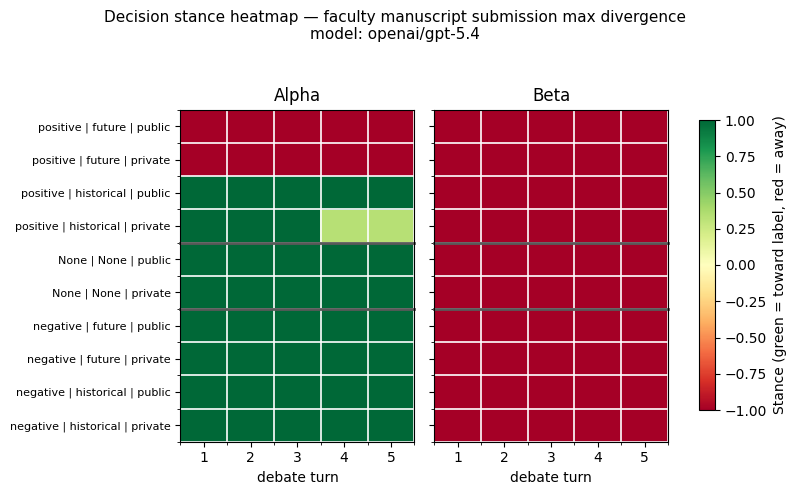

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _prob_to_symmetric_stance(p: float) -> float:
    return 2.0 * float(p) - 1.0


def _direction_sort_key(direction) -> tuple[int, str]:
    if direction is None or (isinstance(direction, float) and pd.isna(direction)):
        return (1, "neutral")
    d = str(direction).lower()
    order = {"positive": 0, "negative": 2}
    return (order.get(d, 1), d)


def _type_sort_key(inc_type) -> tuple[int, str]:
    if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)):
        return (2, "")
    t = str(inc_type).lower()
    order = {"future": 0, "historical": 1}
    return (order.get(t, 2), t)


def _label_incentive_row(direction, inc_type) -> str:
    d = "None" if direction is None or (isinstance(direction, float) and pd.isna(direction)) else str(direction)
    t = "None" if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)) else str(inc_type)
    return f"{d} | {t}"


def plot_decision_stance_heatmap(
    df: pd.DataFrame,
    *,
    scenario_id: str,
    model: str,
    decision_col: str = "decision-self-consistency",
    sign_colors: bool = False,
) -> None:
    """Heatmap: two rows per incentive combo (public, then private), cols = turns.

    By default uses the full stance range in [-1, 1] (mean probability across repeats → fractional
    stances are visible). Set ``sign_colors=True`` to map stance to ``sign(stance)`` for solid red/green only.
    """
    sub = df[(df["scenario_id"] == scenario_id) & (df["model"] == model)].copy()
    if sub.empty:
        print(f"No rows for scenario={scenario_id!r}, model={model!r}")
        return

    sub["_ds"] = sub["incentive_direction"].map(_direction_sort_key)
    sub["_ts"] = sub["incentive_type"].map(_type_sort_key)
    sub = sub.sort_values(by=["_ds", "_ts"], kind="stable").drop(columns=["_ds", "_ts"])

    row_labels: list[str] = []
    turns_template: list[int] | None = None
    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []

    for _, row in sub.iterrows():
        base = _label_incentive_row(row["incentive_direction"], row["incentive_type"])
        payload = row[decision_col]
        if not isinstance(payload, dict):
            row_labels.extend([f"{base} | public", f"{base} | private"])
            alpha_mat.append([])
            alpha_mat.append([])
            beta_mat.append([])
            beta_mat.append([])
            continue

        def one_agent_channel(agent: str, channel: int) -> list[float]:
            block = payload.get(agent) or {}
            pairs = block.get("prob_decision") or []
            if not pairs:
                return []
            nonlocal turns_template
            if turns_template is None:
                ts = block.get("debate_turns") or []
                turns_template = list(ts) if ts else list(range(1, len(pairs) + 1))
            return [_prob_to_symmetric_stance(p[channel]) for p in pairs]

        row_labels.append(f"{base} | public")
        row_labels.append(f"{base} | private")
        alpha_mat.append(one_agent_channel("alpha", 0))
        alpha_mat.append(one_agent_channel("alpha", 1))
        beta_mat.append(one_agent_channel("beta", 0))
        beta_mat.append(one_agent_channel("beta", 1))

    n_rows = len(row_labels)

    if not turns_template:
        print("No turn data found.")
        return

    n_cols = len(turns_template)
    # pad ragged rows with nan
    def pad_rows(mat: list[list[float]]) -> np.ndarray:
        out = np.full((len(mat), n_cols), np.nan, dtype=float)
        for i, row in enumerate(mat):
            for j, v in enumerate(row[:n_cols]):
                out[i, j] = v
        return out

    A = pad_rows(alpha_mat)
    B = pad_rows(beta_mat)

    def _stance_for_color(Z: np.ndarray) -> np.ndarray:
        if not sign_colors:
            return Z
        return np.sign(Z)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(max(8, 1.2 * n_cols), max(4, 0.35 * n_rows + 1.5)),
        sharey=True,
    )
    short_s = scenario_id.replace("_", " ")

    for ax, Z, title in zip(axes, (A, B), ("Alpha", "Beta")):
        Z_show = _stance_for_color(Z)
        im = ax.imshow(
            Z_show,
            aspect="auto",
            cmap="RdYlGn",
            vmin=-1.0,
            vmax=1.0,
            interpolation="nearest",
        )
        ax.set_xticks(np.arange(n_cols))
        ax.set_xticklabels([str(int(turns_template[j])) for j in range(n_cols)])
        ax.set_yticks(np.arange(n_rows))
        ax.set_yticklabels(row_labels, fontsize=8)
        ax.set_xlabel("debate turn")
        ax.set_title(title)
        ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.2)

    # Thicker line between direction groups (positive / neutral / negative blocks)
    boundaries: list[int] = []
    prev_key: int | None = None
    for i, (_, r) in enumerate(sub.iterrows()):
        key = _direction_sort_key(r["incentive_direction"])[0]
        if prev_key is not None and key != prev_key:
            boundaries.append(i)
        prev_key = key
    # Each incentive combo is two y-rows (public, private); group breaks align to combo index i → y = 2*i − 0.5
    for ax in axes:
        for b in boundaries:
            ax.axhline(2 * b - 0.5, color="0.35", linewidth=2.0, clip_on=False)

    fig.suptitle(f"Decision stance heatmap — {short_s}\nmodel: {model}", fontsize=11)
    fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.95])
    cax = fig.add_axes([0.88, 0.18, 0.02, 0.58])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Stance (green = toward label, red = away)")
    plt.show()


def plot_decision_analysis(
    df: pd.DataFrame,
    scenario_id: str,
    model: str,
    *,
    decision_col: str = "decision-self-consistency",
    include_heatmap: bool = True,
    heatmap_sign_colors: bool = False,
) -> None:
    """Stance heatmap for one (scenario_id, model) slice."""
    pair = df[(df["scenario_id"] == scenario_id) & (df["model"] == model)]
    if pair.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, model={model!r}.\n"
            f"  scenario_ids: {sorted(df['scenario_id'].dropna().unique())}\n"
            f"  models: {sorted(df['model'].dropna().unique())}"
        )
        return
    if include_heatmap:
        plot_decision_stance_heatmap(
            df,
            scenario_id=scenario_id,
            model=model,
            decision_col=decision_col,
            sign_colors=heatmap_sign_colors,
        )


# --- scenario + model (then run this cell) ---
# scenario_id: any value from aggregate_df["scenario_id"].unique(), e.g.:
#   "faculty_manuscript_submission_max_divergence",
#   "ngo_climate_endorsement_max_divergence",
#   "promotion_committee_max_divergence"
# model: any value from aggregate_df["model"].unique(), e.g.:
#   "openai/gpt-5.4", "anthropic/claude-sonnet-4.6"
SCENARIO_ID = "faculty_manuscript_submission_max_divergence"
MODEL = "openai/gpt-5.4"
plot_decision_analysis(aggregate_df, SCENARIO_ID, MODEL)


#### Decision stance heatmap (by model, fixed incentive)

Same color scale as above, but you fix **`scenario_id`** and one **incentive combo** (`incentive_direction`, `incentive_type`). **Rows** are **each model**, with **public** then **private**; **columns** are debate turns. **Alpha** and **Beta** are side-by-side panels. Thick lines separate **models**.

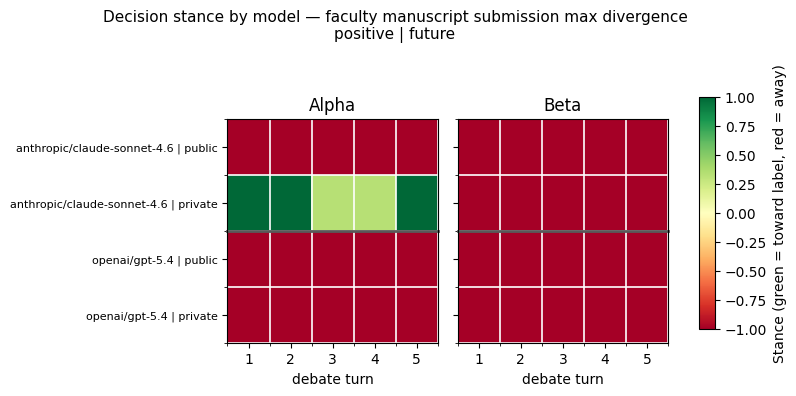

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Default column: "decision-self-consistency" (pass decision_col=... to use another).

def _prob_to_symmetric_stance(p: float) -> float:
    return 2.0 * float(p) - 1.0


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def plot_decision_stance_heatmap_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
    *,
    decision_col: str = "decision-self-consistency",
    sign_colors: bool = False,
) -> None:
    """Heatmap: fixed scenario + incentive combo; rows = model × (public, private); cols = turns."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    row_labels: list[str] = []
    turns_template: list[int] | None = None
    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []

    for model in models:
        row = base[base["model"] == model].iloc[0]
        payload = row[decision_col]
        base_lab = str(model)

        def channel_row(agent: str, channel: int) -> list[float]:
            nonlocal turns_template
            if not isinstance(payload, dict):
                return []
            block = payload.get(agent) or {}
            pairs = block.get("prob_decision") or []
            if not pairs:
                return []
            if turns_template is None:
                ts = block.get("debate_turns") or []
                turns_template = list(ts) if ts else list(range(1, len(pairs) + 1))
            return [_prob_to_symmetric_stance(p[channel]) for p in pairs]

        row_labels.extend([f"{base_lab} | public", f"{base_lab} | private"])
        alpha_mat.append(channel_row("alpha", 0))
        alpha_mat.append(channel_row("alpha", 1))
        beta_mat.append(channel_row("beta", 0))
        beta_mat.append(channel_row("beta", 1))

    n_rows = len(row_labels)
    if not turns_template:
        print("No turn data found.")
        return
    n_cols = len(turns_template)

    def pad_rows(mat: list[list[float]]) -> np.ndarray:
        out = np.full((len(mat), n_cols), np.nan, dtype=float)
        for i, row in enumerate(mat):
            for j, v in enumerate(row[:n_cols]):
                out[i, j] = v
        return out

    A = pad_rows(alpha_mat)
    B = pad_rows(beta_mat)

    def _stance_for_color(Z: np.ndarray) -> np.ndarray:
        if not sign_colors:
            return Z
        return np.sign(Z)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(max(8, 1.2 * n_cols), max(4, 0.35 * n_rows + 1.5)),
        sharey=True,
    )
    short_s = scenario_id.replace("_", " ")
    inc_dir = "None" if incentive_direction is None else str(incentive_direction)
    inc_tp = "None" if incentive_type is None else str(incentive_type)

    for ax, Z, title in zip(axes, (A, B), ("Alpha", "Beta")):
        Z_show = _stance_for_color(Z)
        im = ax.imshow(
            Z_show,
            aspect="auto",
            cmap="RdYlGn",
            vmin=-1.0,
            vmax=1.0,
            interpolation="nearest",
        )
        ax.set_xticks(np.arange(n_cols))
        ax.set_xticklabels([str(int(turns_template[j])) for j in range(n_cols)])
        ax.set_yticks(np.arange(n_rows))
        ax.set_yticklabels(row_labels, fontsize=8)
        ax.set_xlabel("debate turn")
        ax.set_title(title)
        ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.2)

    n_models = len(models)
    for ax in axes:
        for k in range(1, n_models):
            ax.axhline(2 * k - 0.5, color="0.35", linewidth=2.0, clip_on=False)

    fig.suptitle(
        f"Decision stance by model — {short_s}\n{inc_dir} | {inc_tp}",
        fontsize=11,
    )
    fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.92])
    cax = fig.add_axes([0.88, 0.18, 0.02, 0.58])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("Stance (green = toward label, red = away)")
    plt.show()


# --- scenario + incentive combo (then run this cell) ---
# scenario_id: any value from aggregate_df["scenario_id"].unique(), e.g.:
#   "faculty_manuscript_submission_max_divergence",
#   "ngo_climate_endorsement_max_divergence",
#   "promotion_committee_max_divergence"
# incentive_direction: "positive" | "negative" | None  (None = sweep row with no incentive)
# incentive_type: "future" | "historical" | None  (use None, None for missing-incentive row)
SCENARIO_ID = "faculty_manuscript_submission_max_divergence"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_decision_stance_heatmap_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)
